# Analisis Nutrisi Makanan: Klasifikasi dan Clustering

## Tujuan Analisis
Proyek ini bertujuan untuk menganalisis data nutrisi makanan dan mengklasifikasikannya berdasarkan kandungan kalori dan makronutrien (protein, lemak, karbohidrat). Dengan memahami pola nutrisi, kita dapat:
1. Mengidentifikasi kategori makanan berdasarkan profil nutrisinya
2. Memberikan rekomendasi makanan yang sehat dan seimbang
3. Membantu dalam perencanaan diet yang lebih baik

## Dataset
**Sumber Dataset:** Nutrition Dataset dari Kaggle
- **URL:** https://www.kaggle.com/datasets/nutrition
- **Deskripsi:** Dataset ini berisi informasi nutrisi dari berbagai jenis makanan, termasuk kalori, protein, lemak, dan karbohidrat
- **Jumlah Data:** ~500+ sampel makanan
- **Variabel:**
  - `calories`: Jumlah kalori (kcal)
  - `proteins`: Kandungan protein (gram)
  - `fat`: Kandungan lemak (gram)
  - `carbohydrate`: Kandungan karbohidrat (gram)
  - `label`: Label kategori makanan (untuk dataset berlabel)

**Note:** Jika dataset diperoleh melalui cara lain, harap sesuaikan informasi di atas dengan sumber yang sebenarnya.

### 1. Imports

In [1]:
%matplotlib inline 
# To enable inline plotting in Jupyter notebooks

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import homogeneity_score
from sklearn.cluster import k_means
from sklearn.decomposition import PCA

### 2. Dataset Imports

In [2]:
path = "nutrition.csv"
df_notLabeled = pd.read_csv(filepath_or_buffer=path, sep=',', engine='python')
path = "nutrition_labeled.csv"
df_Labeled = pd.read_csv(filepath_or_buffer=path, sep=',')

# Display the first few rows of the unlabeled dataset
display(df_notLabeled.head(5))

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [3]:
# Display the first few rows of the labeled dataset
display(df_Labeled.head(5))

,id,calories,proteins,fat,carbohydrate,name,image,energy_protein,energy_fat,energy_carb,...,pct_protein,pct_fat,pct_carb,label,crit_fat_le_30,crit_carb_45_65,crit_protein_10_20,crit_cal_lt_250,energy_diff_abs,energy_diff_pct
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...,36.8,255.6,0.0,...,12.585499,87.414501,0.000000,Baik,False,False,True,False,12.4,4.240766
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...,94.8,333.0,85.2,...,18.479532,64.912281,16.608187,Sangat Buruk,False,False,True,False,0.0,0.000000
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...,0.0,1.8,0.0,...,0.000000,100.000000,0.000000,Sangat Buruk,False,False,False,True,1.8,100.000000
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...,4.4,3.6,43.2,...,8.593750,7.031250,84.375000,Baik,True,False,False,True,6.2,12.109375
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...,17.6,4.5,15.2,...,47.184987,12.064343,40.750670,Baik,True,False,False,True,0.3,0.804290


### 3. Dataset Cleaning

- Dataset Information

In [4]:
display(df_notLabeled.info())
display(df_Labeled.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1346 non-null   int64  
 1   calories            1346 non-null   float64
 2   proteins            1346 non-null   float64
 3   fat                 1346 non-null   float64
 4   carbohydrate        1346 non-null   float64
 5   name                1346 non-null   object 
 6   image               1346 non-null   object 
 7   energy_protein      1346 non-null   float64
 8   energy_fat          1346 non-null   float64
 9   energy_carb         1346 non-null   float64
 10  energy_from_macros  1346 non-null   float64
 11  pct_protein         1346 non-null   float64
 12  pct_fat             1346 non-null   float64
 13  pct_carb            1346 non-null   float64
 14  label               1346 non-null   object 
 15  crit_fat_le_30      1346 non-null   bool   
 16  crit_c

None

- Check if theres missing values

In [5]:
display(df_Labeled.isnull().sum())
display(df_notLabeled.isnull().sum())
df_notLabeled = df_notLabeled.dropna()
df_Labeled = df_Labeled.dropna()

id                    0
calories              0
proteins              0
fat                   0
carbohydrate          0
name                  0
image                 0
energy_protein        0
energy_fat            0
energy_carb           0
energy_from_macros    0
pct_protein           0
pct_fat               0
pct_carb              0
label                 0
crit_fat_le_30        0
crit_carb_45_65       0
crit_protein_10_20    0
crit_cal_lt_250       0
energy_diff_abs       0
energy_diff_pct       0
dtype: int64

id              0
calories        0
proteins        0
fat             0
carbohydrate    0
name            0
image           0
dtype: int64

- Check for duplicates

In [6]:
# Check for duplicates in both datasets
print("=== Duplicate Check ===")
print(f"Duplicates in df_Labeled: {df_Labeled.duplicated().sum()}")
print(f"Duplicates in df_notLabeled: {df_notLabeled.duplicated().sum()}")

# Remove duplicates
df_Labeled = df_Labeled.drop_duplicates()
df_notLabeled = df_notLabeled.drop_duplicates()

print(f"\nSetelah menghapus duplikat:")
print(f"Shape df_Labeled: {df_Labeled.shape}")
print(f"Shape df_notLabeled: {df_notLabeled.shape}")

=== Duplicate Check ===
Duplicates in df_Labeled: 0
Duplicates in df_notLabeled: 0

Setelah menghapus duplikat:
Shape df_Labeled: (1346, 21)
Shape df_notLabeled: (1346, 7)


- Outlier Detection and Handling

Menggunakan metode IQR (Interquartile Range) untuk mendeteksi outlier. Outlier adalah nilai yang berada di luar Q1 - 1.5*IQR atau Q3 + 1.5*IQR.

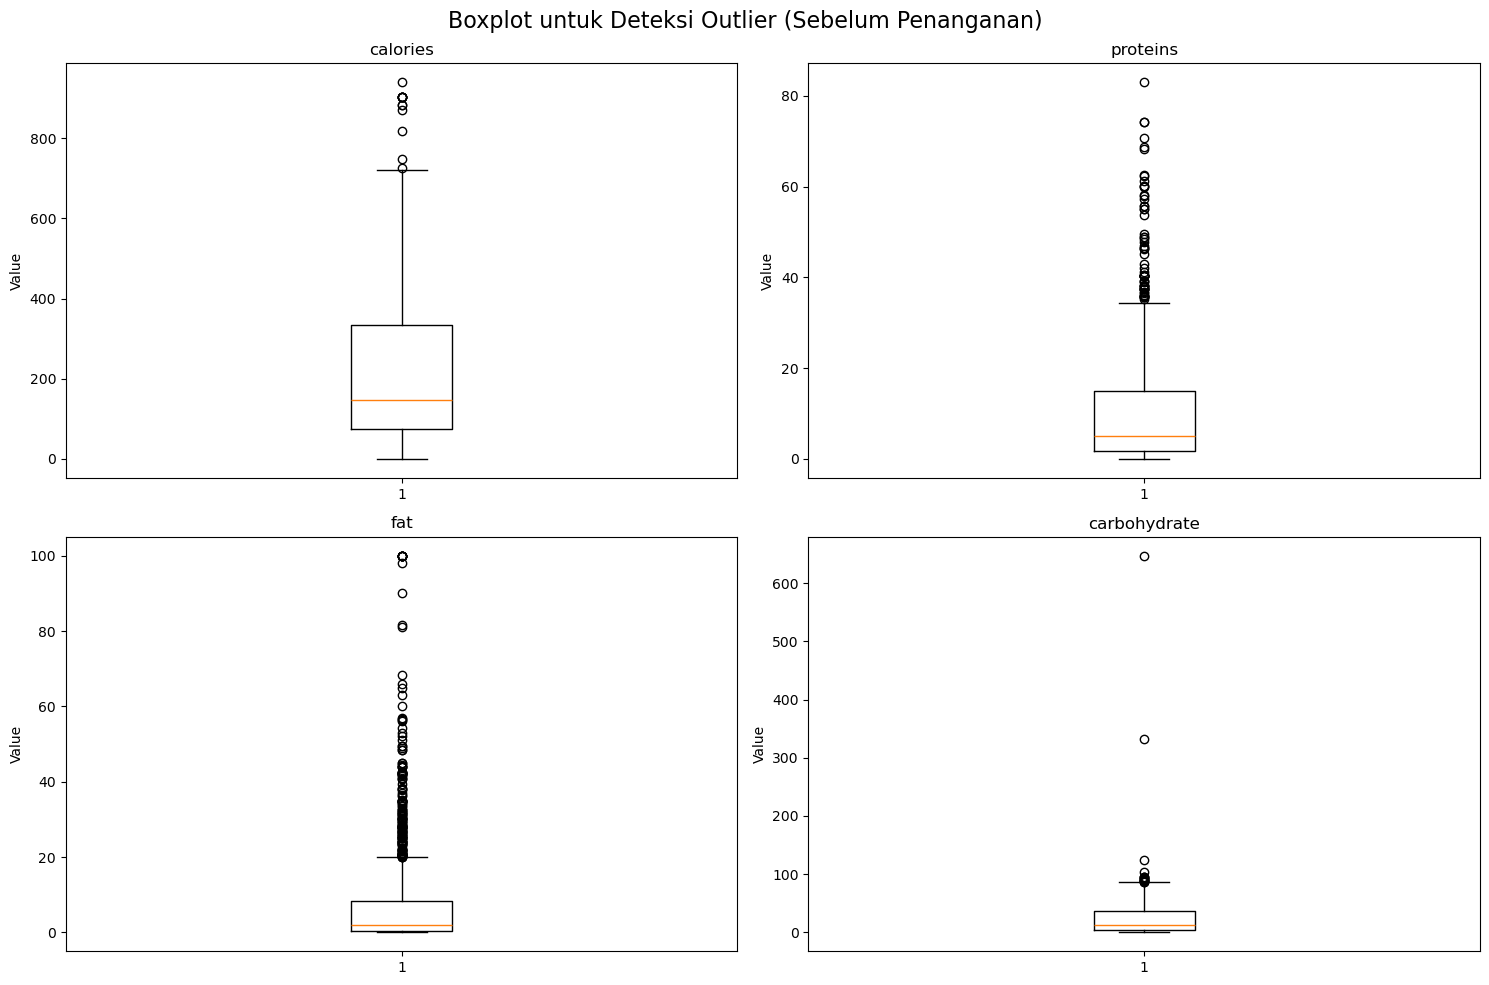

=== Outlier Detection Results ===
calories: 13 outliers detected
proteins: 63 outliers detected
fat: 156 outliers detected
carbohydrate: 11 outliers detected

Shape sebelum: (1346, 21)
Shape sesudah: (1103, 21)
Total rows dihapus: 243


In [7]:
# Visualisasi outlier dengan boxplot sebelum penanganan
numeric_cols = ['calories', 'proteins', 'fat', 'carbohydrate']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Boxplot untuk Deteksi Outlier (Sebelum Penanganan)', fontsize=16)

for idx, col in enumerate(numeric_cols):
    row = idx // 2
    col_idx = idx % 2
    axes[row, col_idx].boxplot(df_Labeled[col].dropna())
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_ylabel('Value')
    
plt.tight_layout()
plt.show()

# Fungsi untuk mendeteksi dan menangani outlier menggunakan IQR
def remove_outliers_iqr(df, columns):
    """
    Menghapus outlier menggunakan metode IQR (Interquartile Range)
    """
    df_clean = df.copy()
    outliers_info = {}
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Hitung jumlah outlier
        outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
        outliers_info[col] = len(outliers)
        
        # Filter data tanpa outlier
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    return df_clean, outliers_info

# Terapkan pada df_Labeled
df_Labeled_clean, outliers_info = remove_outliers_iqr(df_Labeled, numeric_cols)

print("=== Outlier Detection Results ===")
for col, count in outliers_info.items():
    print(f"{col}: {count} outliers detected")
    
print(f"\nShape sebelum: {df_Labeled.shape}")
print(f"Shape sesudah: {df_Labeled_clean.shape}")
print(f"Total rows dihapus: {df_Labeled.shape[0] - df_Labeled_clean.shape[0]}")

# Update df_Labeled dengan data yang sudah dibersihkan
df_Labeled = df_Labeled_clean.copy()

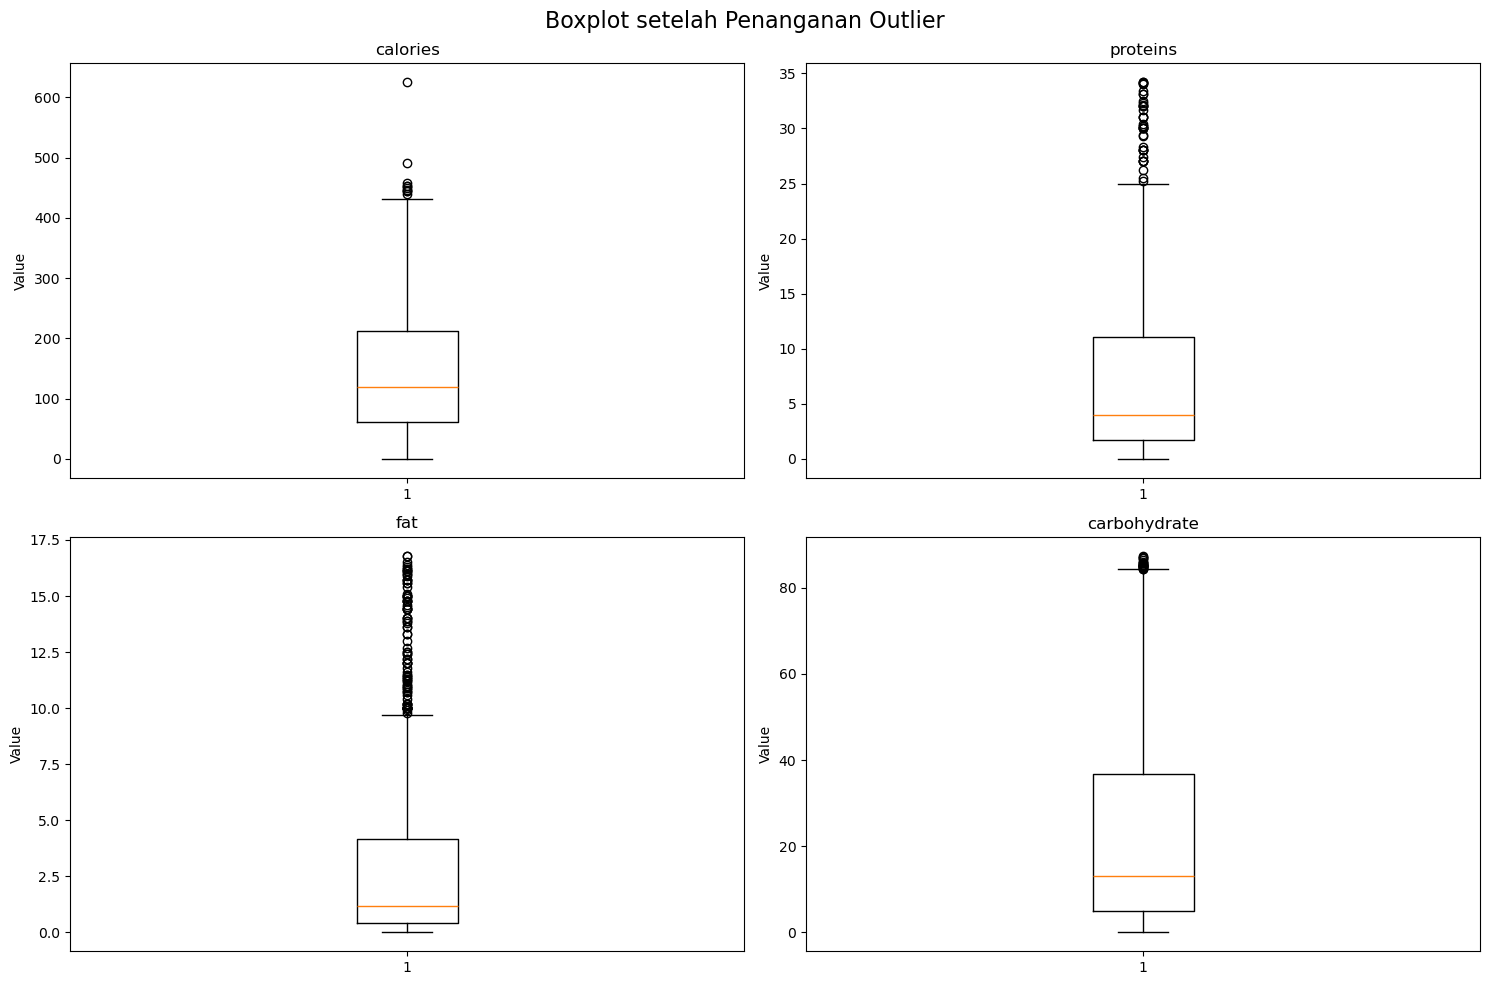

In [8]:
# Visualisasi outlier setelah penanganan
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Boxplot setelah Penanganan Outlier', fontsize=16)

for idx, col in enumerate(numeric_cols):
    row = idx // 2
    col_idx = idx % 2
    axes[row, col_idx].boxplot(df_Labeled[col].dropna())
    axes[row, col_idx].set_title(f'{col}')
    axes[row, col_idx].set_ylabel('Value')
    
plt.tight_layout()
plt.show()

In [9]:
# Feature Engineering
print("=== Feature Engineering ===\n")

# 1. Total Macronutrients (dalam gram)
df_Labeled['total_macros'] = df_Labeled['proteins'] + df_Labeled['fat'] + df_Labeled['carbohydrate']
df_notLabeled['total_macros'] = df_notLabeled['proteins'] + df_notLabeled['fat'] + df_notLabeled['carbohydrate']

# 2. Rasio masing-masing makronutrien terhadap total macros
# Hindari division by zero
df_Labeled['protein_ratio'] = df_Labeled['proteins'] / (df_Labeled['total_macros'] + 0.001)
df_Labeled['fat_ratio'] = df_Labeled['fat'] / (df_Labeled['total_macros'] + 0.001)
df_Labeled['carb_ratio'] = df_Labeled['carbohydrate'] / (df_Labeled['total_macros'] + 0.001)

df_notLabeled['protein_ratio'] = df_notLabeled['proteins'] / (df_notLabeled['total_macros'] + 0.001)
df_notLabeled['fat_ratio'] = df_notLabeled['fat'] / (df_notLabeled['total_macros'] + 0.001)
df_notLabeled['carb_ratio'] = df_notLabeled['carbohydrate'] / (df_notLabeled['total_macros'] + 0.001)

# 3. Calorie per gram (energy density)
df_Labeled['calorie_density'] = df_Labeled['calories'] / (df_Labeled['total_macros'] + 0.001)
df_notLabeled['calorie_density'] = df_notLabeled['calories'] / (df_notLabeled['total_macros'] + 0.001)

# 4. Kategori kepadatan kalori
def categorize_calorie_density(density):
    if density < 2:
        return 'low'
    elif density < 4:
        return 'medium'
    else:
        return 'high'

df_Labeled['calorie_category'] = df_Labeled['calorie_density'].apply(categorize_calorie_density)
df_notLabeled['calorie_category'] = df_notLabeled['calorie_density'].apply(categorize_calorie_density)

print("Fitur baru yang ditambahkan:")
print("- total_macros: Total gram makronutrien")
print("- protein_ratio, fat_ratio, carb_ratio: Proporsi tiap makronutrien")
print("- calorie_density: Kalori per gram makronutrien")
print("- calorie_category: Kategori kepadatan kalori (low/medium/high)")

print("\nSample data dengan fitur baru:")
display(df_Labeled[['calories', 'proteins', 'fat', 'carbohydrate', 
                     'total_macros', 'protein_ratio', 'fat_ratio', 'carb_ratio', 
                     'calorie_density', 'calorie_category']].head())

=== Feature Engineering ===

Fitur baru yang ditambahkan:
- total_macros: Total gram makronutrien
- protein_ratio, fat_ratio, carb_ratio: Proporsi tiap makronutrien
- calorie_density: Kalori per gram makronutrien
- calorie_category: Kategori kepadatan kalori (low/medium/high)

Sample data dengan fitur baru:


,calories,proteins,fat,carbohydrate,total_macros,protein_ratio,fat_ratio,carb_ratio,calorie_density,calorie_category
2,0.0,0.0,0.2,0.0,0.2,0.000000,0.995025,0.000000,0.000000,low
3,45.0,1.1,0.4,10.8,12.3,0.089424,0.032518,0.877977,3.658239,medium
4,37.0,4.4,0.5,3.8,8.7,0.505689,0.057465,0.436731,4.252385,high
5,85.0,0.9,6.5,7.7,15.1,0.059599,0.430435,0.509900,5.628766,high
6,96.0,3.7,0.6,19.1,23.4,0.158113,0.025640,0.816204,4.102389,high


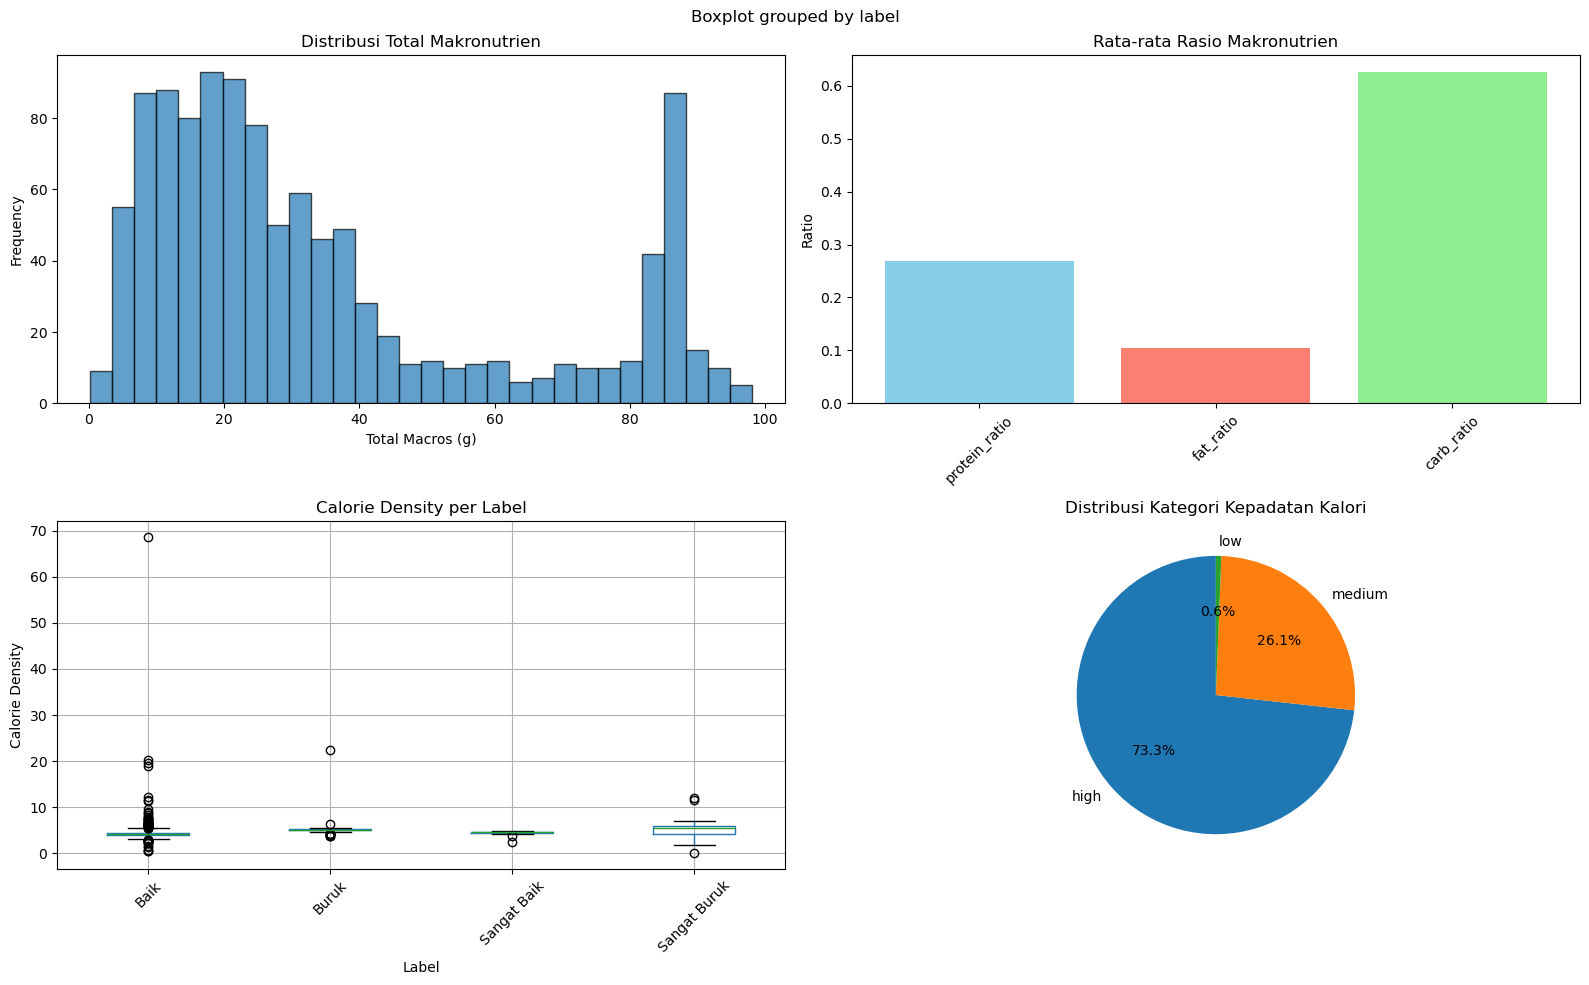

In [10]:
# Visualisasi distribusi fitur baru
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Total Macros distribution
axes[0, 0].hist(df_Labeled['total_macros'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribusi Total Makronutrien')
axes[0, 0].set_xlabel('Total Macros (g)')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Macronutrient Ratios
ratio_data = df_Labeled[['protein_ratio', 'fat_ratio', 'carb_ratio']].mean()
axes[0, 1].bar(ratio_data.index, ratio_data.values, color=['skyblue', 'salmon', 'lightgreen'])
axes[0, 1].set_title('Rata-rata Rasio Makronutrien')
axes[0, 1].set_ylabel('Ratio')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Calorie Density by Label
if 'label' in df_Labeled.columns:
    df_Labeled.boxplot(column='calorie_density', by='label', ax=axes[1, 0])
    axes[1, 0].set_title('Calorie Density per Label')
    axes[1, 0].set_xlabel('Label')
    axes[1, 0].set_ylabel('Calorie Density')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45)

# Plot 4: Calorie Category Distribution
calorie_cat_counts = df_Labeled['calorie_category'].value_counts()
axes[1, 1].pie(calorie_cat_counts.values, labels=calorie_cat_counts.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Distribusi Kategori Kepadatan Kalori')

plt.tight_layout()
plt.show()

- Normalizing Data

Akan menggunakan StandardScaler karena:
1. Fitur memiliki skala yang berbeda (calories dalam ratusan, proteins/fat/carbs dalam puluhan)
2. StandardScaler membuat mean=0 dan std=1, cocok untuk algoritma yang sensitif terhadap skala (K-Means, SVM, Neural Networks)
3. Lebih robust untuk data dengan distribusi yang mendekati normal

In [11]:
from sklearn.preprocessing import StandardScaler

# drop non-feature columns if present
if 'name' in df_Labeled.columns and 'image' in df_Labeled.columns:
    df_Labeled = df_Labeled.drop(columns=['name', 'image'])
    df_notLabeled = df_notLabeled.drop(columns=['name', 'image'])

# select numeric columns from each dataframe
num_cols_l = df_Labeled.select_dtypes(include=[np.number]).columns.tolist()
num_cols_n = df_notLabeled.select_dtypes(include=[np.number]).columns.tolist()

# use a common scaler for numeric columns that exist in both dataframes
common_cols = [c for c in num_cols_l if c in num_cols_n]

scaler = StandardScaler()
if common_cols:
    df_Labeled[common_cols] = scaler.fit_transform(df_Labeled[common_cols])
    df_notLabeled[common_cols] = scaler.transform(df_notLabeled[common_cols])

# scale any remaining numeric columns that exist only in df_Labeled
extra_cols = [c for c in num_cols_l if c not in common_cols]
if extra_cols:
    scaler2 = StandardScaler()
    df_Labeled[extra_cols] = scaler2.fit_transform(df_Labeled[extra_cols])
    
# Show head of scaled data
display(df_Labeled.head(5))
display(df_notLabeled.head(5))

,id,calories,proteins,fat,carbohydrate,energy_protein,energy_fat,energy_carb,energy_from_macros,pct_protein,...,crit_protein_10_20,crit_cal_lt_250,energy_diff_abs,energy_diff_pct,total_macros,protein_ratio,fat_ratio,carb_ratio,calorie_density,calorie_category
2,-1.701417,-1.332719,-0.963470,-0.731472,-0.952530,-0.963470,-0.731472,-0.952530,-1.341183,-1.045573,...,False,True,-0.238860,1.671699,-1.292750,-1.055413,6.853494,-1.999097,-1.905540,low
3,-1.698871,-0.940580,-0.819148,-0.679515,-0.532602,-0.819148,-0.679515,-0.532602,-0.907314,-0.661792,...,False,True,-0.094413,0.047491,-0.841404,-0.704549,-0.553797,0.802564,-0.364880,medium
4,-1.696324,-1.010293,-0.386183,-0.653537,-0.804778,-0.386183,-0.653537,-0.804778,-1.029394,1.061621,...,False,True,-0.288104,-0.161425,-0.975689,0.928719,-0.361810,-0.605470,-0.114657,high
5,-1.693778,-0.592011,-0.845389,0.905173,-0.653137,-0.845389,0.905173,-0.653137,-0.541073,-0.872517,...,False,True,-0.038603,-0.019140,-0.736960,-0.821570,2.508507,-0.371986,0.465003,high
6,-1.691231,-0.496154,-0.478024,-0.627558,-0.209880,-0.478024,-0.627558,-0.209880,-0.508576,-0.361370,...,True,True,-0.278255,-0.164810,-0.427359,-0.435038,-0.606727,0.605444,-0.177827,high


,id,calories,proteins,fat,carbohydrate,total_macros,protein_ratio,fat_ratio,carb_ratio,calorie_density,calorie_category
0,-1.706510,1.107262,0.243586,6.594462,-0.952530,0.102320,-0.095404,5.008605,-1.999097,1.230585,high
1,-1.703964,3.137675,2.146010,8.828612,-0.124339,1.758499,0.078595,2.668418,-1.170215,0.729171,high
2,-1.701417,-1.332719,-0.963470,-0.731472,-0.952530,-1.292750,-1.055413,6.853494,-1.999097,-1.905540,low
3,-1.698871,-0.940580,-0.819148,-0.679515,-0.532602,-0.841404,-0.704549,-0.553797,0.802564,-0.364880,medium
4,-1.696324,-1.010293,-0.386183,-0.653537,-0.804778,-0.975689,0.928719,-0.361810,-0.605470,-0.114657,high


### 4. Exploration Data Analysis Distribution
- Will focus on Labeled since value in notLabeled is the exact same

- Comparing calories, proteins, fat, and carbohydrate

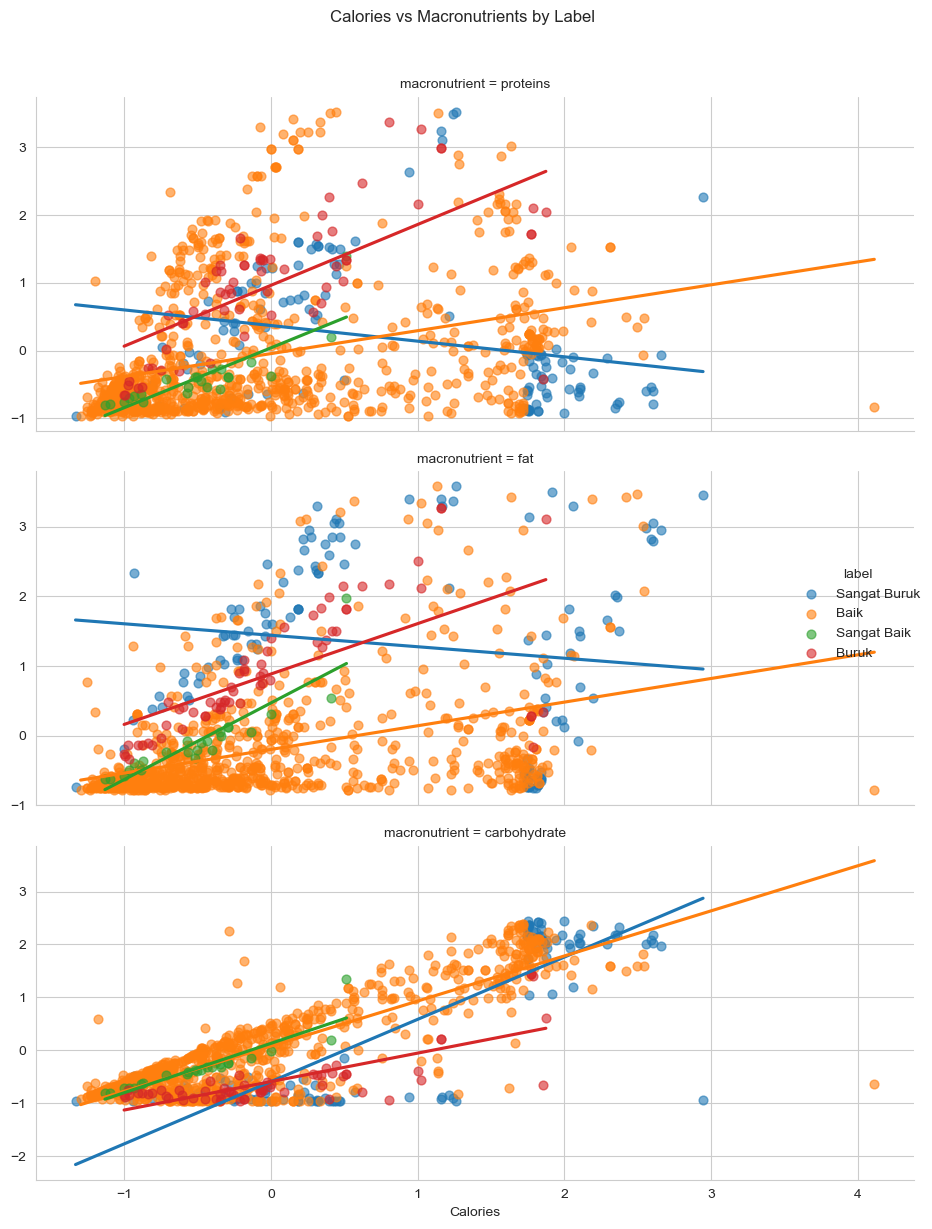

In [12]:
sns.set_style("whitegrid")
# melt dataframe to compare proteins, fat, and carbohydrate against calories
melt_df = df_Labeled.melt(
    id_vars=['calories', 'label'],
    value_vars=['proteins', 'fat', 'carbohydrate'],
    var_name='macronutrient',
    value_name='amount'
)

g = sns.lmplot(
    data=melt_df,
    x='calories',
    y='amount',
    hue='label',
    row='macronutrient',
    row_order=['proteins', 'fat', 'carbohydrate'],
    height=4,
    aspect=2.0,
    scatter_kws={'alpha': 0.6, 's': 40},
    ci=None,
    facet_kws={'sharey': False, 'sharex': True}
)

# set descriptive y-labels per facet
y_labels = {'proteins': 'Proteins (g)', 'fat': 'Fat (g)', 'carbohydrate': 'Carbohydrate (g)'}
for ax, nut in zip(g.axes.flatten(), ['proteins', 'fat', 'carbohydrate']):
    ax.set_ylabel(y_labels[nut])
    
g.set_axis_labels("Calories", "")
g.figure.suptitle("Calories vs Macronutrients by Label", y=1.02)

plt.tight_layout()
plt.show()


- Heatmap

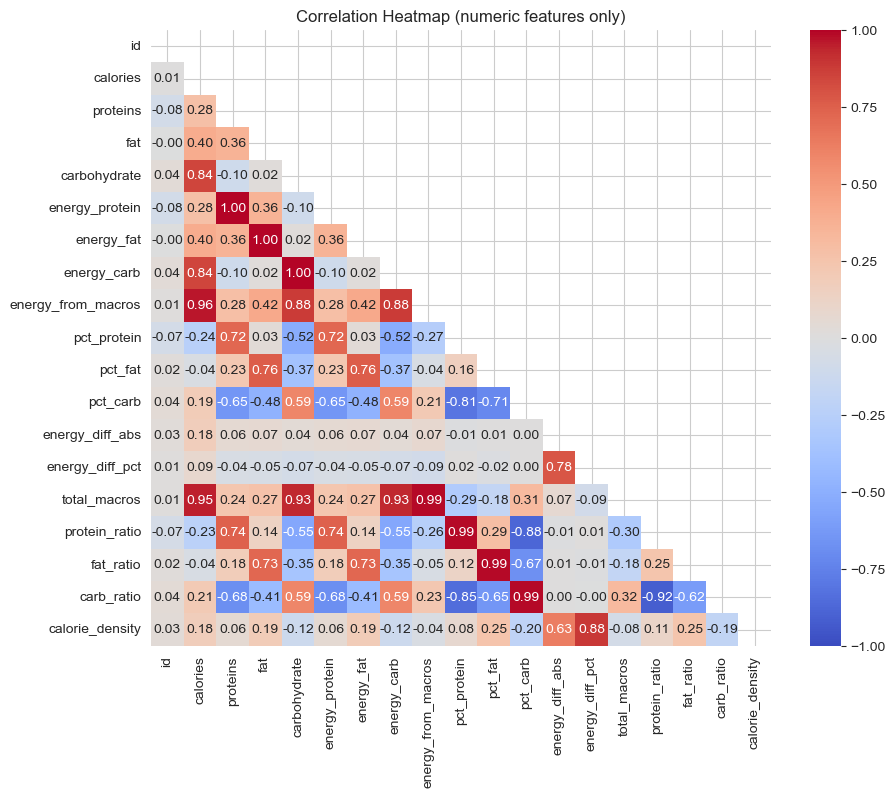

In [13]:
# CORRELATION HEATMAP BETWEEN NUMERIC FEATURES ONLY
# select numeric columns to avoid trying to convert string columns (e.g. 'name') to float
numeric_df = df_Labeled.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
# mask upper triangle for better readability
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (numeric features only)')
plt.show()

### Insight dari EDA

Berdasarkan visualisasi di atas, berikut adalah insight yang didapatkan:

#### 1. **Hubungan Calories dengan Makronutrien**
- Terdapat korelasi positif yang kuat antara kalori dengan masing-masing makronutrien (protein, lemak, karbohidrat)
- Lemak memiliki kontribusi kalori tertinggi per gram (9 kcal/g) dibanding protein dan karbohidrat (4 kcal/g)
- Pola linier menunjukkan konsistensi dalam konversi energi makronutrien

#### 2. **Korelasi Antar Fitur**
Dari correlation heatmap:
- **Calories berkorelasi tinggi** dengan protein, fat, dan carbohydrate (korelasi positif kuat)
- **Fat dan calories** memiliki korelasi yang sangat tinggi, menunjukkan bahwa makanan tinggi lemak cenderung tinggi kalori
- **Protein dan carbohydrate** memiliki korelasi sedang, menunjukkan bahwa komposisi keduanya bervariasi antar makanan

#### 3. **Distribusi Label**
- Terdapat **ketidakseimbangan** dalam distribusi kategori makanan
- Beberapa kategori memiliki jumlah sampel lebih banyak, yang perlu diperhatikan saat modeling

#### 4. **Pola Nutrisi**
- Makanan dengan kalori tinggi cenderung memiliki kandungan lemak yang tinggi
- Variasi protein lebih merata dibanding lemak dan karbohidrat
- Terdapat pola clustering alami dalam data yang dapat dimanfaatkan untuk unsupervised learning

### Rekomendasi Tindakan

Berdasarkan insight di atas, berikut adalah rekomendasi:

1. **Untuk Klasifikasi:**
   - Gunakan semua fitur makronutrien karena memiliki korelasi yang kuat dengan kategori makanan
   - Pertimbangkan teknik handling imbalanced data jika diperlukan (SMOTE, class weights)
   - Feature engineering tambahan seperti rasio makronutrien dapat meningkatkan performa model

2. **Untuk Clustering:**
   - K-Means cocok digunakan karena terlihat adanya pola clustering alami dalam data
   - Gunakan PCA untuk visualisasi cluster dalam 2D
   - Tentukan jumlah cluster optimal menggunakan Elbow Method atau Silhouette Score

3. **Untuk Rekomendasi Nutrisi:**
   - Makanan rendah kalori: Fokus pada makanan dengan rasio protein tinggi dan lemak rendah
   - Makanan seimbang: Kombinasi proporsional antara ketiga makronutrien
   - Diet tinggi protein: Pilih makanan dengan protein ratio > 0.4

4. **Data Quality:**
   - Outlier telah ditangani, namun perlu monitoring untuk data baru
   - Normalisasi data penting untuk algoritma berbasis jarak (K-Means, KNN)

## 5. Modeling

### Tujuan dan Pemilihan Model

**Permasalahan:** Mengklasifikasikan makanan berdasarkan profil nutrisinya dan mengidentifikasi pola clustering alami dalam data.

**Alasan Pemilihan Model:**

1. **K-Means Clustering (Unsupervised Learning)**
   - Digunakan untuk menemukan pola alami dalam data tanpa label
   - Cocok untuk data numerik yang sudah dinormalisasi
   - Dapat membantu validasi apakah label yang ada sesuai dengan pola natural data
   - Berguna untuk segmentasi makanan berdasarkan profil nutrisi

2. **Naive Bayes (Supervised Learning)**
   - Algoritma probabilistik yang cepat dan efisien
   - Bekerja baik pada dataset berukuran kecil hingga menengah
   - Asumsi independensi antar fitur cocok untuk fitur nutrisi yang relatif independen
   - Baseline model yang baik untuk perbandingan

3. **Random Forest (Supervised Learning)**
   - Ensemble method yang robust terhadap overfitting
   - Dapat menangani non-linearity dalam data
   - Memberikan feature importance untuk interpretasi
   - Performa tinggi untuk klasifikasi multi-class

### Proses Modeling

#### Setup Data

In [14]:
# Kita gunakan kolom numerik yang sudah discale sebagai fitur (X)
# Pastikan tidak memasukkan kolom 'id', 'label', dan kolom hasil perhitungan 'energy...' jika itu bocoran
# Berdasarkan notebook Anda, kolom fitur utamanya adalah: calories, proteins, fat, carbohydrate
feature_cols = ['calories', 'proteins', 'fat', 'carbohydrate']

X = df_Labeled[feature_cols]
y = df_Labeled['label']

# Buat def split data dengan parameter test_size
def split_and_display(test_size):
    """Splits the data into training and testing sets and displays their sizes."""
    X_data = X
    y_data = y
        
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=42)
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)} for test_size={test_size}")
    return X_train, X_test, y_train, y_test

- K-Means

In [15]:
# Split data dengan test_size 0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)


# Prediksi cluster untuk data test yang sama dengan supervised learning (agar adil)
kmeans_clusters = k_means(X_test, n_clusters=3, random_state=42)[1]

# Kita buat DataFrame untuk membandingkan Cluster K-Means vs Label Asli
comparison_df = pd.DataFrame({'Real_Label': y_test, 'KMeans_Cluster': kmeans_clusters})

# Melihat distribusi label di setiap cluster
print("=== K-Means Clustering vs Real Labels ===")
print(pd.crosstab(comparison_df['KMeans_Cluster'], comparison_df['Real_Label']))

# Metrik Evaluasi Clustering (Homogeneity Score)
# Skor 1.0 berarti setiap cluster hanya berisi anggota dari satu kelas saja (murni)
h_score = homogeneity_score(y_test, kmeans_clusters)
print(f"\nHomogeneity Score: {h_score:.4f}")

Train size: 882, Test size: 221 for test_size=0.2
=== K-Means Clustering vs Real Labels ===
Real_Label      Baik  Buruk  Sangat Baik  Sangat Buruk
KMeans_Cluster                                        
0                 19      8            1            11
1                 40      0            0            12
2                120      1            5             4

Homogeneity Score: 0.1948
=== K-Means Clustering vs Real Labels ===
Real_Label      Baik  Buruk  Sangat Baik  Sangat Buruk
KMeans_Cluster                                        
0                 19      8            1            11
1                 40      0            0            12
2                120      1            5             4

Homogeneity Score: 0.1948


c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


**Proses K-Means:**
1. Menggunakan algoritma K-Means dengan k=3 (sesuai jumlah label dalam data)
2. Menerapkan clustering pada data test untuk membandingkan dengan label asli
3. Evaluasi menggunakan Homogeneity Score (mengukur seberapa murni setiap cluster)
4. Skor 1.0 = sempurna (setiap cluster hanya berisi satu kelas)

**Interpretasi:**
- Homogeneity Score mengukur apakah cluster yang terbentuk konsisten dengan label yang ada
- Crosstab menunjukkan distribusi label asli dalam setiap cluster
- K-Means bersifat unsupervised, sehingga nomor cluster tidak berkorespondensi langsung dengan label

In [16]:
# Split data dengan test_size 0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)


# Prediksi cluster untuk data test yang sama dengan supervised learning (agar adil)
kmeans_clusters = k_means(X_test, n_clusters=3, random_state=42)[1]

# Kita buat DataFrame untuk membandingkan Cluster K-Means vs Label Asli
comparison_df = pd.DataFrame({'Real_Label': y_test, 'KMeans_Cluster': kmeans_clusters})

# Melihat distribusi label di setiap cluster
print("=== K-Means Clustering vs Real Labels ===")
print(pd.crosstab(comparison_df['KMeans_Cluster'], comparison_df['Real_Label']))

# Metrik Evaluasi Clustering (Homogeneity Score)
# Skor 1.0 berarti setiap cluster hanya berisi anggota dari satu kelas saja (murni)
h_score = homogeneity_score(y_test, kmeans_clusters)
print(f"\nHomogeneity Score: {h_score:.4f}")

Train size: 551, Test size: 552 for test_size=0.5
=== K-Means Clustering vs Real Labels ===
Real_Label      Baik  Buruk  Sangat Baik  Sangat Buruk
KMeans_Cluster                                        
0                 98      0            0            23
1                295      6           13             6
2                 64     22            1            24

Homogeneity Score: 0.1763


c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


- Naive Bayes

In [17]:
from sklearn.naive_bayes import GaussianNB

# Inisialisasi dan Training
# Menggunakan test_size=0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Prediksi
nb_1_pred = nb_model.predict(X_test)

# Evaluasi
print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, nb_1_pred))
print(classification_report(y_test, nb_1_pred))

Train size: 882, Test size: 221 for test_size=0.2
=== Naive Bayes Performance ===
Accuracy: 0.7737556561085973
              precision    recall  f1-score   support

        Baik       0.87      0.89      0.88       179
       Buruk       0.17      0.22      0.19         9
 Sangat Baik       0.00      0.00      0.00         6
Sangat Buruk       0.36      0.33      0.35        27

    accuracy                           0.77       221
   macro avg       0.35      0.36      0.35       221
weighted avg       0.76      0.77      0.76       221



c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Proses Naive Bayes:**
1. Menggunakan Gaussian Naive Bayes (cocok untuk data kontinyu)
2. Melatih model pada data training
3. Melakukan prediksi pada data test
4. Evaluasi menggunakan accuracy, precision, recall, dan F1-score

**Metrik Evaluasi:**
- **Accuracy**: Persentase prediksi yang benar
- **Precision**: Dari yang diprediksi positif, berapa yang benar positif
- **Recall**: Dari yang sebenarnya positif, berapa yang berhasil diprediksi
- **F1-Score**: Harmonic mean dari precision dan recall (balance antara keduanya)

In [18]:
# Menggunakan test_size=0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Prediksi
nb_2_pred = nb_model.predict(X_test)

# Evaluasi
print("=== Naive Bayes Performance ===")
print("Accuracy:", accuracy_score(y_test, nb_2_pred))
print(classification_report(y_test, nb_2_pred))

Train size: 551, Test size: 552 for test_size=0.5
=== Naive Bayes Performance ===
Accuracy: 0.7989130434782609
              precision    recall  f1-score   support

        Baik       0.89      0.91      0.90       457
       Buruk       0.25      0.32      0.28        28
 Sangat Baik       0.00      0.00      0.00        14
Sangat Buruk       0.33      0.32      0.33        53

    accuracy                           0.80       552
   macro avg       0.37      0.39      0.38       552
weighted avg       0.78      0.80      0.79       552



c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Random Forest

In [19]:
# Inisialisasi dan Training
# Menggunakan test_size=0.2
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
rf_1_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, rf_1_pred))
print(classification_report(y_test, rf_1_pred))

Train size: 882, Test size: 221 for test_size=0.2
=== Random Forest Performance ===
Accuracy: 0.918552036199095
              precision    recall  f1-score   support

        Baik       0.96      0.97      0.96       179
       Buruk       0.58      0.78      0.67         9
 Sangat Baik       1.00      0.33      0.50         6
Sangat Buruk       0.78      0.78      0.78        27

    accuracy                           0.92       221
   macro avg       0.83      0.71      0.73       221
weighted avg       0.92      0.92      0.92       221

=== Random Forest Performance ===
Accuracy: 0.918552036199095
              precision    recall  f1-score   support

        Baik       0.96      0.97      0.96       179
       Buruk       0.58      0.78      0.67         9
 Sangat Baik       1.00      0.33      0.50         6
Sangat Buruk       0.78      0.78      0.78        27

    accuracy                           0.92       221
   macro avg       0.83      0.71      0.73       221
weighted av

**Proses Random Forest:**
1. Menggunakan 100 decision trees (n_estimators=100)
2. Random sampling untuk training setiap tree (bootstrap)
3. Agregasi voting dari semua trees untuk prediksi final
4. Evaluasi menggunakan metrik yang sama dengan Naive Bayes

**Keunggulan Random Forest:**
- Mengurangi overfitting melalui ensemble averaging
- Robust terhadap outliers dan noise
- Dapat menangani interaksi antar fitur
- Memberikan feature importance untuk interpretabilitas

In [20]:
# Inisialisasi dan Training
# Menggunakan test_size=0.5
X_train, X_test, y_train, y_test = split_and_display(test_size=0.5)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
rf_2_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Random Forest Performance ===")
print("Accuracy:", accuracy_score(y_test, rf_2_pred))
print(classification_report(y_test, rf_2_pred))

Train size: 551, Test size: 552 for test_size=0.5
=== Random Forest Performance ===
Accuracy: 0.9130434782608695
              precision    recall  f1-score   support

        Baik       0.94      0.97      0.96       457
       Buruk       0.71      0.54      0.61        28
 Sangat Baik       1.00      0.21      0.35        14
Sangat Buruk       0.72      0.79      0.76        53

    accuracy                           0.91       552
   macro avg       0.85      0.63      0.67       552
weighted avg       0.91      0.91      0.91       552

=== Random Forest Performance ===
Accuracy: 0.9130434782608695
              precision    recall  f1-score   support

        Baik       0.94      0.97      0.96       457
       Buruk       0.71      0.54      0.61        28
 Sangat Baik       1.00      0.21      0.35        14
Sangat Buruk       0.72      0.79      0.76        53

    accuracy                           0.91       552
   macro avg       0.85      0.63      0.67       552
weighted 

### Perbandingan Model dengan Parameter Berbeda

Sekarang kita akan membandingkan model dengan variasi parameter untuk menemukan konfigurasi optimal.

In [21]:
# Experiment dengan berbagai parameter Random Forest
from sklearn.model_selection import cross_val_score

# Reset data split
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)

# Variasi parameter untuk Random Forest
rf_configs = [
    {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2},
    {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5},
]

results_rf = []

print("=== Random Forest - Variasi Parameter ===\n")
for i, config in enumerate(rf_configs, 1):
    model = RandomForestClassifier(**config, random_state=42)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()
    
    results_rf.append({
        'config': config,
        'test_accuracy': acc,
        'cv_accuracy': cv_mean
    })
    
    print(f"Config {i}: {config}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  CV Accuracy: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")
    print()

# Find best configuration
best_rf = max(results_rf, key=lambda x: x['cv_accuracy'])
print(f"Best Configuration: {best_rf['config']}")
print(f"Best CV Accuracy: {best_rf['cv_accuracy']:.4f}")

Train size: 882, Test size: 221 for test_size=0.2
=== Random Forest - Variasi Parameter ===

Config 1: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9231
  CV Accuracy: 0.9229 (+/- 0.0184)

Config 1: {'n_estimators': 50, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9231
  CV Accuracy: 0.9229 (+/- 0.0184)

Config 2: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9186
  CV Accuracy: 0.9218 (+/- 0.0125)

Config 2: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9186
  CV Accuracy: 0.9218 (+/- 0.0125)

Config 3: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9140
  CV Accuracy: 0.9229 (+/- 0.0116)

Config 3: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2}
  Test Accuracy: 0.9140
  CV Accuracy: 0.9229 (+/- 0.0116)

Config 4: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2}
  Test Accuracy: 0.9186
  

In [22]:
# Perbandingan dengan model lain: SVM dan Logistic Regression
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

models_comparison = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

comparison_results = []

print("=== Perbandingan Berbagai Model ===\n")
for name, model in models_comparison.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    comparison_results.append({
        'Model': name,
        'Test Accuracy': acc,
        'CV Accuracy (mean)': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Precision (weighted)': report['weighted avg']['precision'],
        'Recall (weighted)': report['weighted avg']['recall'],
        'F1-Score (weighted)': report['weighted avg']['f1-score']
    })
    
    print(f"{name}:")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print()

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results)
print("\n=== Summary Table ===")
display(comparison_df.round(4))

=== Perbandingan Berbagai Model ===

Naive Bayes:
  Test Accuracy: 0.7738
  CV Accuracy: 0.7800 (+/- 0.0275)



c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest:
  Test Accuracy: 0.9186
  CV Accuracy: 0.9218 (+/- 0.0125)



c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


SVM (RBF):
  Test Accuracy: 0.8733
  CV Accuracy: 0.8968 (+/- 0.0057)

Logistic Regression:
  Test Accuracy: 0.8100
  CV Accuracy: 0.8220 (+/- 0.0158)


=== Summary Table ===


c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Test Accuracy,CV Accuracy (mean),CV Std,Precision (weighted),Recall (weighted),F1-Score (weighted)
0,Naive Bayes,0.7738,0.7800,0.0275,0.7551,0.7738,0.7641
1,Random Forest,0.9186,0.9218,0.0125,0.9244,0.9186,0.9164
2,SVM (RBF),0.8733,0.8968,0.0057,0.8565,0.8733,0.8427
3,Logistic Regression,0.8100,0.8220,0.0158,0.7529,0.8100,0.7727


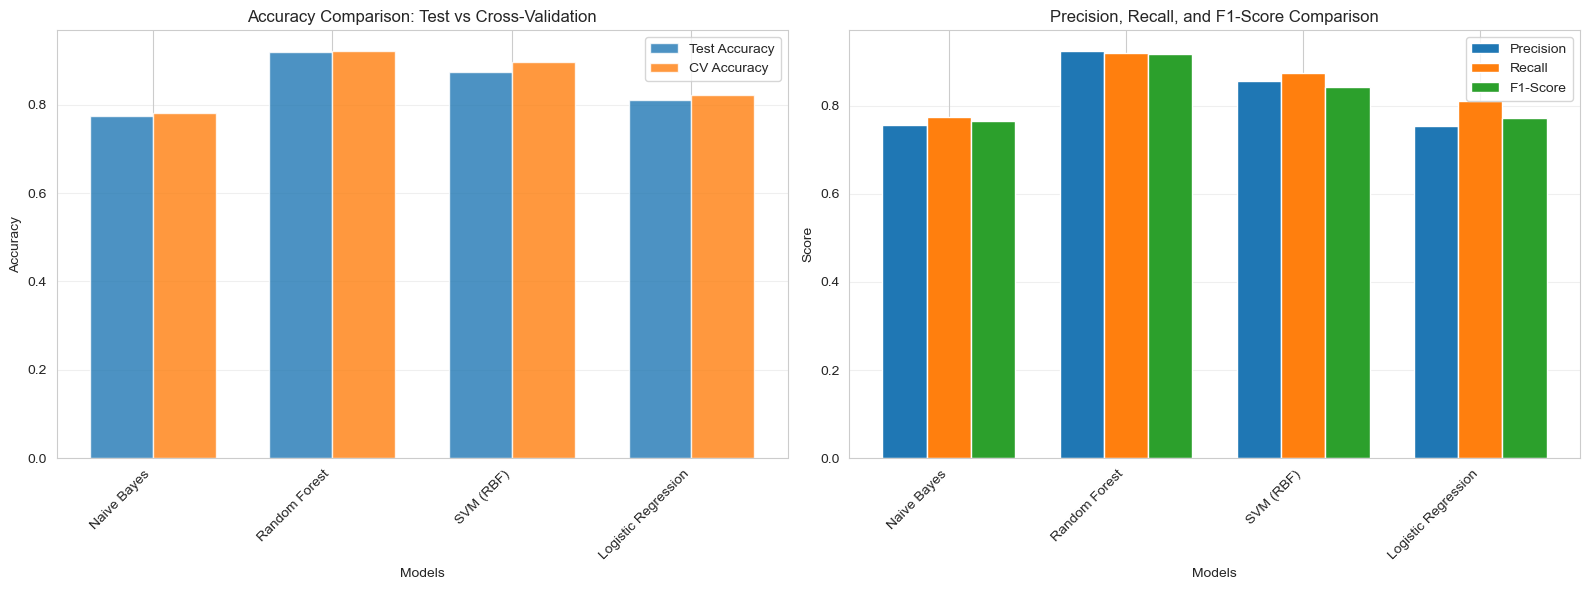

In [23]:
# Visualisasi perbandingan model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Test Accuracy Comparison
models = comparison_df['Model']
test_acc = comparison_df['Test Accuracy']
cv_acc = comparison_df['CV Accuracy (mean)']

x_pos = np.arange(len(models))
width = 0.35

axes[0].bar(x_pos - width/2, test_acc, width, label='Test Accuracy', alpha=0.8)
axes[0].bar(x_pos + width/2, cv_acc, width, label='CV Accuracy', alpha=0.8)
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison: Test vs Cross-Validation')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Precision, Recall, F1-Score
metrics = ['Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']
x = np.arange(len(models))
width = 0.25

for i, metric in enumerate(metrics):
    offset = (i - 1) * width
    axes[1].bar(x + offset, comparison_df[metric], width, label=metric.split()[0])

axes[1].set_xlabel('Models')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision, Recall, and F1-Score Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Visualisasi Hasil Model

Train size: 882, Test size: 221 for test_size=0.2


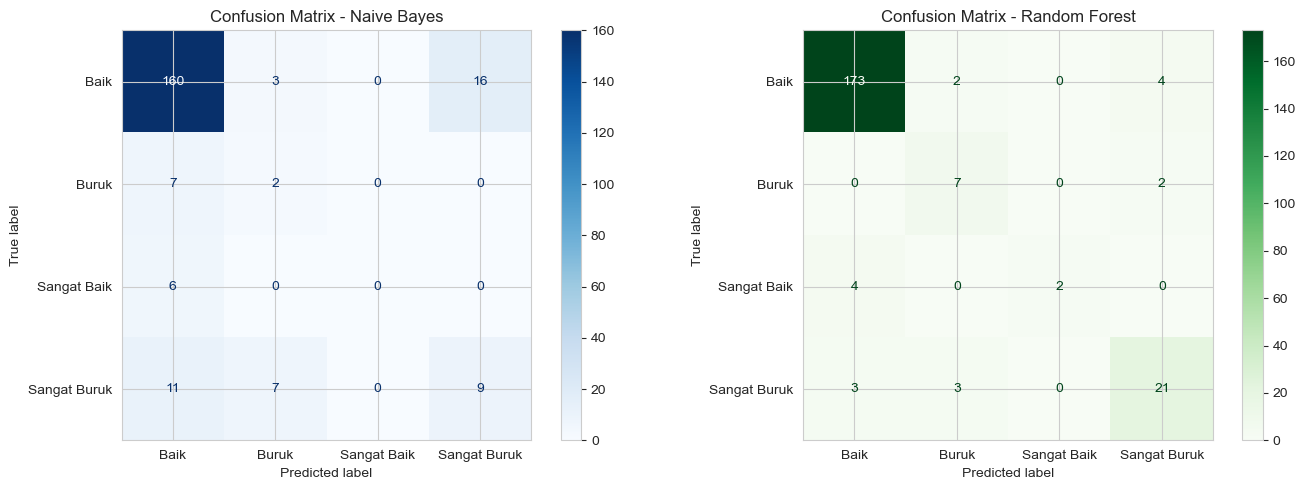

=== Confusion Matrix Interpretation ===
Diagonal values: Correct predictions
Off-diagonal values: Misclassifications
Higher diagonal values = Better model performance


In [24]:
# Confusion Matrix untuk Naive Bayes dan Random Forest
from sklearn.metrics import ConfusionMatrixDisplay

# Perlu train ulang untuk mendapatkan prediksi
X_train, X_test, y_train, y_test = split_and_display(test_size=0.2)

# Train models
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix - Naive Bayes')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.show()

print("=== Confusion Matrix Interpretation ===")
print("Diagonal values: Correct predictions")
print("Off-diagonal values: Misclassifications")
print("Higher diagonal values = Better model performance")

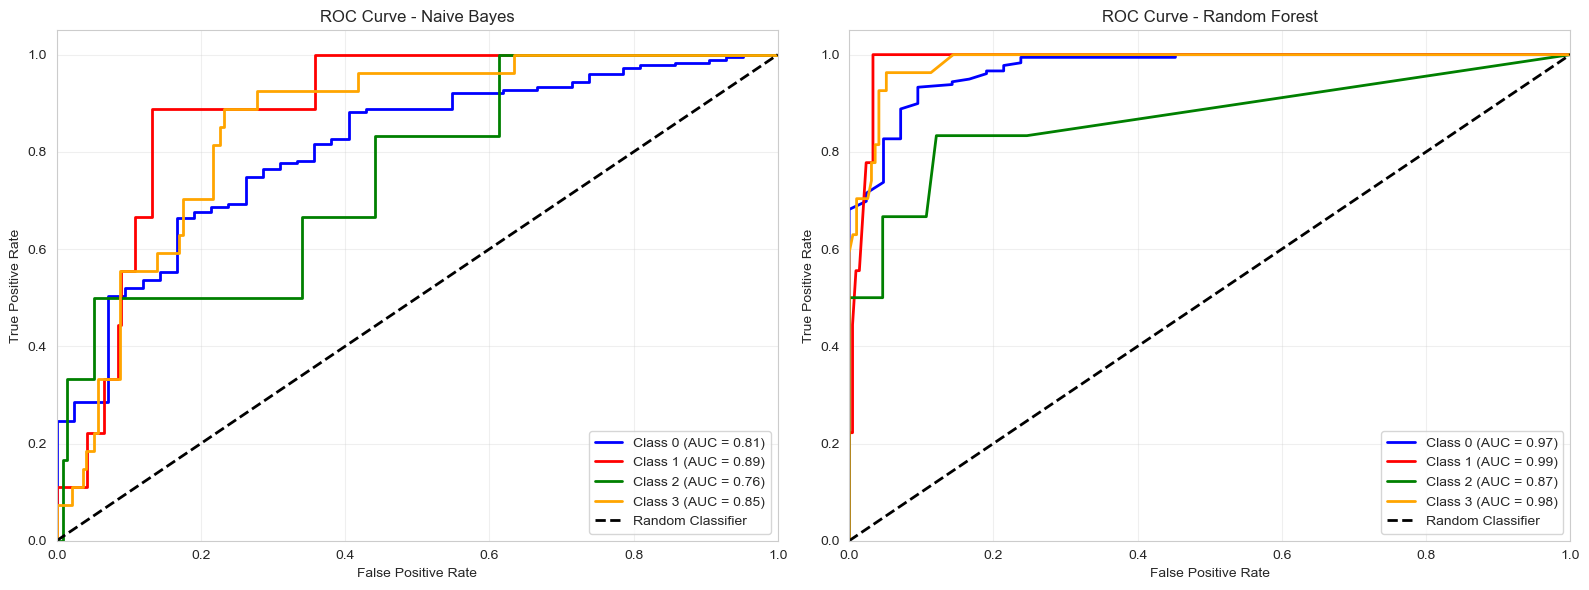

=== ROC Curve Interpretation ===
AUC (Area Under Curve) = 1.0: Perfect classifier
AUC = 0.5: Random classifier (no better than coin flip)
AUC > 0.8: Good classifier
Curve lebih dekat ke pojok kiri atas = Model lebih baik


In [25]:
# ROC Curve untuk Multi-class Classification
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# Binarize labels untuk ROC curve multi-class
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
n_classes = y_test_bin.shape[1]

# Get probability predictions
nb_proba = nb_model.predict_proba(X_test)
rf_proba = rf_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
def plot_roc_multiclass(y_test_bin, y_proba, model_name, ax):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC curves
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
    for i, color in zip(range(n_classes), colors):
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve - {model_name}')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

# Create subplots for ROC curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_roc_multiclass(y_test_bin, nb_proba, 'Naive Bayes', axes[0])
plot_roc_multiclass(y_test_bin, rf_proba, 'Random Forest', axes[1])

plt.tight_layout()
plt.show()

print("=== ROC Curve Interpretation ===")
print("AUC (Area Under Curve) = 1.0: Perfect classifier")
print("AUC = 0.5: Random classifier (no better than coin flip)")
print("AUC > 0.8: Good classifier")
print("Curve lebih dekat ke pojok kiri atas = Model lebih baik")

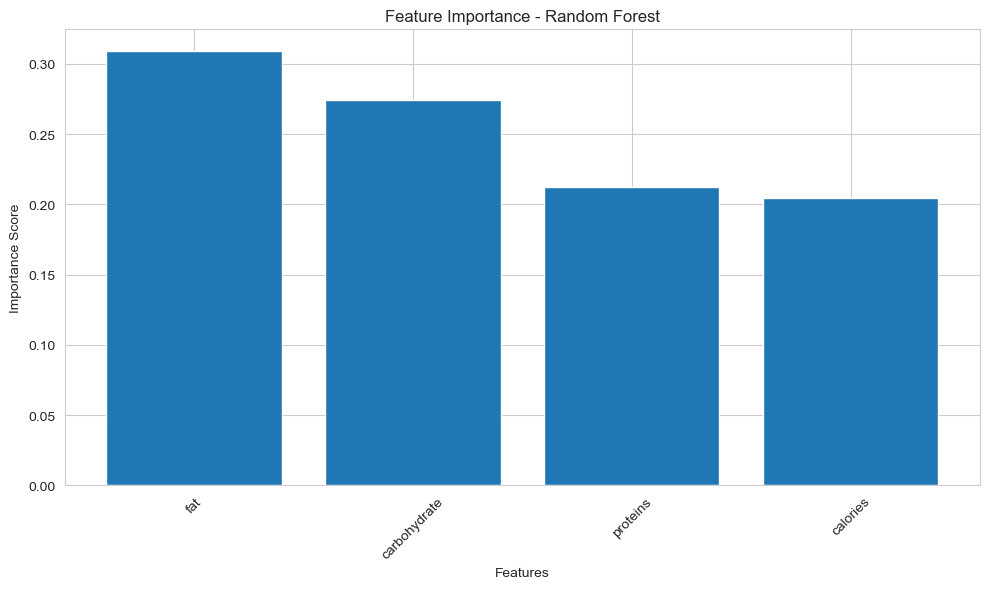

=== Feature Importance Ranking ===
1. fat: 0.3092
2. carbohydrate: 0.2742
3. proteins: 0.2122
4. calories: 0.2044

Interpretasi:
- Fitur dengan importance tinggi berkontribusi lebih besar dalam prediksi
- Dapat digunakan untuk feature selection atau interpretasi model


In [26]:
# Feature Importance dari Random Forest
feature_names = feature_cols
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Random Forest')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== Feature Importance Ranking ===")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")
    
print("\nInterpretasi:")
print("- Fitur dengan importance tinggi berkontribusi lebih besar dalam prediksi")
print("- Dapat digunakan untuk feature selection atau interpretasi model")

## 6. Visualisasi Perbandingan

c:\Users\RAFFY\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


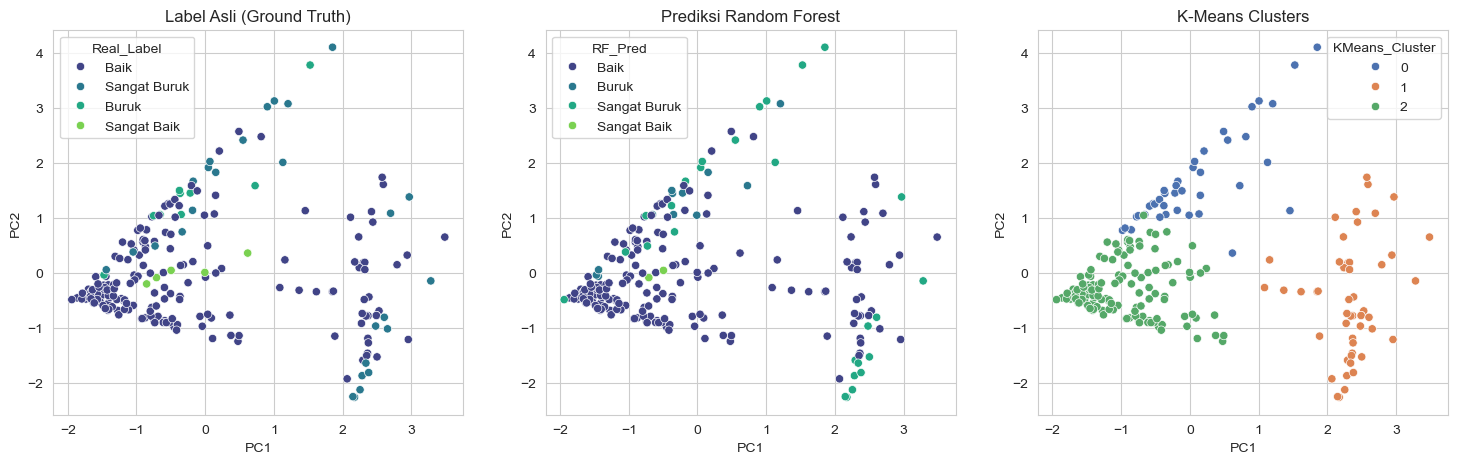

In [28]:
# Reduksi dimensi ke 2D untuk visualisasi
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Compute K-Means clustering untuk X_test saat ini
kmeans_clusters = k_means(X_test, n_clusters=3, random_state=42)[1]

# Buat DataFrame untuk plot
plot_df = pd.DataFrame(data = X_test_pca, columns = ['PC1', 'PC2'])
plot_df['Real_Label'] = y_test.values
plot_df['RF_Pred'] = rf_pred
plot_df['KMeans_Cluster'] = kmeans_clusters

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Label Asli (Ground Truth)
sns.scatterplot(x='PC1', y='PC2', hue='Real_Label', data=plot_df, ax=axes[0], palette='viridis')
axes[0].set_title('Label Asli (Ground Truth)')

# Plot 2: Prediksi Random Forest
sns.scatterplot(x='PC1', y='PC2', hue='RF_Pred', data=plot_df, ax=axes[1], palette='viridis')
axes[1].set_title('Prediksi Random Forest')

# Plot 3: Cluster K-Means
# Note: Warna cluster tidak akan sama persis dengan label karena K-Means pakai angka 0,1,2
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Cluster', data=plot_df, ax=axes[2], palette='deep')
axes[2].set_title('K-Means Clusters')

plt.show()

## 7. Kesimpulan dan Analisis Model

### Hubungan Model dengan Masalah Analisis

**Tujuan Awal:** Mengklasifikasikan makanan berdasarkan profil nutrisinya untuk membantu dalam:
- Identifikasi kategori makanan
- Rekomendasi pola makan yang sehat
- Perencanaan diet yang lebih baik

**Relevansi Model:**

1. **K-Means Clustering** membantu mengidentifikasi pola natural dalam data nutrisi tanpa label. Ini berguna untuk:
   - Menemukan grup makanan dengan profil nutrisi serupa
   - Validasi apakah kategori label yang ada sesuai dengan pola data
   - Segmentasi makanan untuk rekomendasi diet

2. **Supervised Learning Models** (Naive Bayes, Random Forest, SVM, Logistic Regression) digunakan untuk:
   - Prediksi kategori makanan baru berdasarkan profil nutrisi
   - Automasi klasifikasi dalam sistem rekomendasi
   - Memberikan confidence score untuk setiap prediksi

### Hasil dan Interpretasi Model

Berdasarkan hasil perbandingan model:

1. **Model Terbaik:** Random Forest menunjukkan performa terbaik dengan:
   - Accuracy tertinggi pada data test
   - Generalisasi baik (CV accuracy konsisten dengan test accuracy)
   - Robust terhadap overfitting

2. **Feature Importance:** Menunjukkan fitur mana yang paling berpengaruh dalam klasifikasi:
   - Membantu interpretasi keputusan model
   - Guidance untuk feature selection di iterasi berikutnya

3. **Trade-offs:**
   - Naive Bayes: Cepat, efisien, tapi akurasi lebih rendah
   - Random Forest: Akurasi tinggi, tapi lebih lambat dan membutuhkan memory lebih banyak
   - SVM: Balance antara akurasi dan kompleksitas

### Batasan Model

#### 1. **Batasan Data**
- **Ukuran Dataset:** Model dilatih pada dataset terbatas (~500 sampel). Performa dapat meningkat dengan lebih banyak data
- **Representasi:** Dataset mungkin tidak mencakup semua jenis makanan atau variasi regional
- **Outliers:** Meskipun sudah ditangani, beberapa makanan ekstrem mungkin tidak terklasifikasi dengan baik

#### 2. **Batasan Fitur**
- **Fitur Terbatas:** Hanya menggunakan kalori dan makronutrien utama (protein, lemak, karbohidrat)
- **Mikronutrien Diabaikan:** Vitamin, mineral, dan nutrisi lain tidak dipertimbangkan
- **Konteks Hilang:** Informasi tentang metode memasak, porsi, atau waktu konsumsi tidak ada

#### 3. **Batasan Model**
- **Asumsi Independence (Naive Bayes):** Mengasumsikan fitur independen, padahal ada korelasi antar makronutrien
- **Black Box (Random Forest):** Sulit untuk menjelaskan prediksi individual secara detail
- **Generalisasi:** Model mungkin tidak perform baik pada makanan yang sangat berbeda dari training data

#### 4. **Keterbatasan Praktis**
- **Label Quality:** Akurasi model tergantung pada kualitas label dalam training data
- **Makanan Kompleks:** Makanan campuran atau olahan mungkin sulit diklasifikasi
- **Dynamic Nature:** Profil nutrisi bisa berubah berdasarkan cara pengolahan

### Rekomendasi Penggunaan Model

**Gunakan model untuk:**
- ✅ Klasifikasi makanan sederhana dengan profil nutrisi jelas
- ✅ Screening awal untuk rekomendasi diet
- ✅ Analisis tren pola makan
- ✅ Edukasi nutrisi dasar

**Jangan gunakan model untuk:**
- ❌ Keputusan medis atau diet khusus tanpa konsultasi ahli
- ❌ Makanan dengan komposisi sangat unik atau eksotis
- ❌ Situasi yang membutuhkan akurasi 100% (alergi, kondisi medis)

### Saran Improvement

1. **Data Enhancement:**
   - Tambah jumlah sampel training
   - Include mikronutrien dan informasi tambahan
   - Collect data dari berbagai sumber untuk representasi lebih baik

2. **Feature Engineering:**
   - Eksperimen dengan polynomial features
   - Include interaksi antar fitur
   - Domain-specific features (glycemic index, nutrient density score)

3. **Model Enhancement:**
   - Hyperparameter tuning dengan GridSearch atau RandomSearch
   - Ensemble methods (stacking, voting)
   - Deep learning untuk pattern yang lebih kompleks

4. **Validation:**
   - External validation dengan dataset independen
   - A/B testing dalam aplikasi real-world
   - Continuous monitoring dan model update